In [1]:
import pytorch3d.structures
import pytorch3d.io
import pytorch3d.renderer
import torch
import imageio
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
def torus_points(step, R, r):
    points = [] # (x, y, z)
    theta = 0
    phi = 0
    while theta < 2 * math.pi:
        phi = 0
        while phi < 2 * math.pi:
            points.append(
                [
                    (R + r * math.sin(theta)) * math.cos(phi),
                    r * math.cos(theta),
                    (R + r * math.sin(theta)) * math.sin(phi),
                    
                ]
            )
            phi += step
        theta += step
    return points

In [3]:
points = torus_points(0.07, 3, 1)
point_cloud = torch.Tensor(points).unsqueeze(0)

In [4]:
point_cloud.shape

torch.Size([1, 8100, 3])

In [5]:
# Color for each point based on its coord
# find min and max
point_min = float("inf")
point_max = float("-inf")
for point in points:
    for coord in point:
        if coord < point_min:
            point_min = coord
        if coord > point_max:
            point_max = coord
            
print(point_min, point_max)
rgbs = []
for point in points:
    rgbs.append(
        [ (c - point_min) / (point_max - point_min) for c in point ]
    )
print(rgbs)

-3.999384481248718 3.999525830605479
[[0.8750422505520278, 0.6250081931584791, 0.4999911644617048], [0.8741237505371853, 0.6250081931584791, 0.5262233053198961], [0.8713727493052654, 0.6250081931584791, 0.5523269611654521], [0.8668027212589086, 0.6250081931584791, 0.5781742763052644], [0.8604360503931708, 0.6250081931584791, 0.6036386506028713], [0.8523039206587273, 0.6250081931584791, 0.6285953595658623], [0.8424461632228981, 0.6250081931584791, 0.6529221652463787], [0.8309110613766102, 0.6250081931584791, 0.6764999149625205], [0.8177551140428636, 0.6250081931584791, 0.6992131249081214], [0.8030427590450349, 0.6250081931584791, 0.7209505457923734], [0.7868460574904503, 0.6250081931584791, 0.7416057077387969], [0.76924434081512, 0.6250081931584791, 0.7610774417746411], [0.7503238222184034, 0.6250081931584791, 0.7792703753564623], [0.7301771743908027, 0.6250081931584791, 0.7960953995047925], [0.7089030756031721, 0.6250081931584791, 0.8114701052598757], [0.6866057263805969, 0.62500819315

In [6]:

rgb_tensor = torch.Tensor(rgbs).unsqueeze(0)
pointCloud = pytorch3d.structures.Pointclouds(point_cloud, features=rgb_tensor)

In [39]:
# Camera and renderer
R, T = pytorch3d.renderer.look_at_view_transform(dist=6.0, elev=40, azim=20.0, up=( (-0.2, 0.0,0.0), )  )
cameras = pytorch3d.renderer.PerspectiveCameras(
    R=R, T=T
)

renderer = pytorch3d.renderer.PointsRenderer(rasterizer = pytorch3d.renderer.PointsRasterizer(cameras=cameras, raster_settings=pytorch3d.renderer.PointsRasterizationSettings(image_size=500, radius=0.01)), compositor=pytorch3d.renderer.AlphaCompositor())


In [40]:
rend = renderer(point_clouds=pointCloud, cameras=cameras)

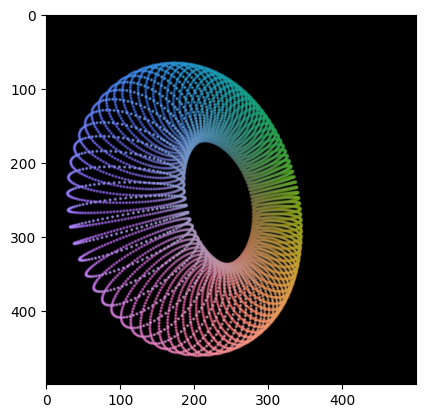

In [41]:
plt.plot(figsize=(10,10))
plt.imshow(rend.squeeze(0))

In [42]:
frames = []

for azim in range(0, 360, 10):
    # Camera and renderer
    R, T = pytorch3d.renderer.look_at_view_transform(dist=6.0, elev=40, azim=azim, up=( (-0.2, 0.0,0.0), ) )
    cameras = pytorch3d.renderer.PerspectiveCameras(
        R=R, T=T
    )
    
    renderer = pytorch3d.renderer.PointsRenderer(rasterizer = pytorch3d.renderer.PointsRasterizer(cameras=cameras, raster_settings=pytorch3d.renderer.PointsRasterizationSettings(image_size=500, radius=0.01)), compositor=pytorch3d.renderer.AlphaCompositor())
    rend = renderer(point_clouds=pointCloud, cameras=cameras)
    frames.append((rend.squeeze(0).numpy() * 255).astype(np.uint8))


In [43]:
imageio.mimwrite("spinning_torus_pointcloud.gif", frames, duration=1, loop=0)

In [117]:
# Hyperboloid func

def sample_hyperboloid(step, step_v, v_min, v_max, a, b, c):
    points = []
    theta = 0
    v = v_min
    while v <= v_max:
        theta = 0
        while theta < 2 * math.pi:
            points.append(
                [
                    a * math.cosh(v) * math.cos(theta),
                    c * math.sinh(v),
                    b * math.cosh(v) * math.sin(theta)
                ]
            )
            theta += step
        v += step_v
    return points

In [142]:
# Color for each point based on its coord
# find min and max
points_2 = sample_hyperboloid(0.07, 0.07, -2, 2, 1, 1, 1)

point_min = float("inf")
point_max = float("-inf")
for point in points_2:
    for coord in point:
        if coord < point_min:
            point_min = coord
        if coord > point_max:
            point_max = coord
            
print(point_min, point_max)
rgbs_2 = []
for point in points_2:
    rgbs_2.append(
        [ (c - point_min) / (point_max - point_min) for c in point ]
    )


-3.762062729336798 3.7621956910836314


In [143]:
point_cloud_2 = torch.Tensor(points_2).unsqueeze(0)
rgb_tensor_2 = torch.Tensor(rgbs_2).unsqueeze(0)
print(point_cloud_2.shape, rgb_tensor_2.shape)
pointCloud2 = pytorch3d.structures.Pointclouds(point_cloud_2, features=rgb_tensor_2)

torch.Size([1, 5220, 3]) torch.Size([1, 5220, 3])


In [156]:
# Camera and renderer
R, T = pytorch3d.renderer.look_at_view_transform(dist=8.0, elev=0) 
cameras = pytorch3d.renderer.PerspectiveCameras(
    R=R, T=T
)

renderer = pytorch3d.renderer.PointsRenderer(rasterizer = pytorch3d.renderer.PointsRasterizer(cameras=cameras, raster_settings=pytorch3d.renderer.PointsRasterizationSettings(image_size=500, radius=0.01)), compositor=pytorch3d.renderer.AlphaCompositor())


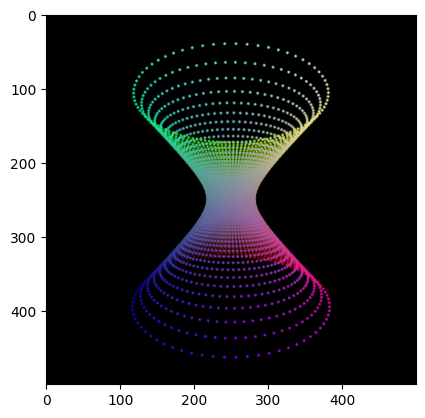

In [157]:
rend = renderer(point_clouds=pointCloud2, cameras=cameras)
plt.plot(figsize=(10,10))
plt.imshow(rend.squeeze(0))

In [158]:
frames2 = []

for elev in range(0, 360, 10):
    # Camera and renderer
    R, T = pytorch3d.renderer.look_at_view_transform(dist=6.0, elev=elev, azim=0.00)
    cameras = pytorch3d.renderer.PerspectiveCameras(
        R=R, T=T
    )
    
    renderer = pytorch3d.renderer.PointsRenderer(rasterizer = pytorch3d.renderer.PointsRasterizer(cameras=cameras, raster_settings=pytorch3d.renderer.PointsRasterizationSettings(image_size=500, radius=0.01)), compositor=pytorch3d.renderer.AlphaCompositor())
    rend = renderer(point_clouds=pointCloud2, cameras=cameras)
    frames2.append((rend.squeeze(0).numpy() * 255).astype(np.uint8))


In [159]:
imageio.mimwrite("spinning_hyperboloid_pointcloud.gif", frames2, duration=1, loop=0)